In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 

In [2]:
df = pd.read_csv('../data/raw/house_data.csv')

In [3]:
X = df.drop(['id','date','price','sqft_above','sqft_basement','sqft_living15','sqft_lot15','zipcode','waterfront',
                'view','yr_renovated'],axis=1)

y = df['price']

In [4]:
df_ml = X.copy()

# Add target column
df_ml['price'] = y

# Check
print(df_ml.head())
print(df_ml.shape)

   bedrooms  bathrooms  sqft_living  sqft_lot  floors  condition  grade  \
0         3       1.00         1180      5650     1.0          3      7   
1         3       2.25         2570      7242     2.0          3      7   
2         2       1.00          770     10000     1.0          3      6   
3         4       3.00         1960      5000     1.0          5      7   
4         3       2.00         1680      8080     1.0          3      8   

   yr_built      lat     long     price  
0      1955  47.5112 -122.257  221900.0  
1      1951  47.7210 -122.319  538000.0  
2      1933  47.7379 -122.233  180000.0  
3      1965  47.5208 -122.393  604000.0  
4      1987  47.6168 -122.045  510000.0  
(21613, 11)


In [5]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   bedrooms     21613 non-null  int64  
 1   bathrooms    21613 non-null  float64
 2   sqft_living  21613 non-null  int64  
 3   sqft_lot     21613 non-null  int64  
 4   floors       21613 non-null  float64
 5   condition    21613 non-null  int64  
 6   grade        21613 non-null  int64  
 7   yr_built     21613 non-null  int64  
 8   lat          21613 non-null  float64
 9   long         21613 non-null  float64
 10  price        21613 non-null  float64
dtypes: float64(5), int64(6)
memory usage: 1.8 MB


In [6]:
df_ml.to_csv(
    "../data/processed/preprocessed.csv",
    index=False
)

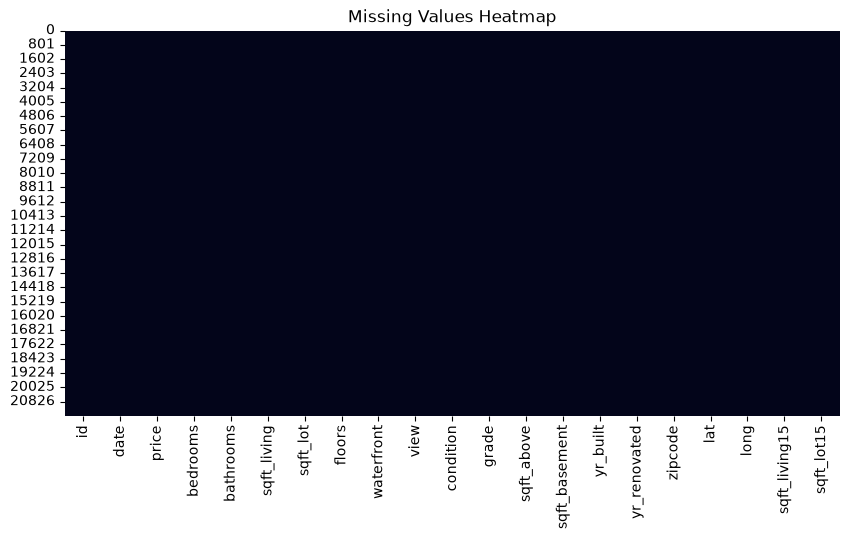

In [7]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.show()

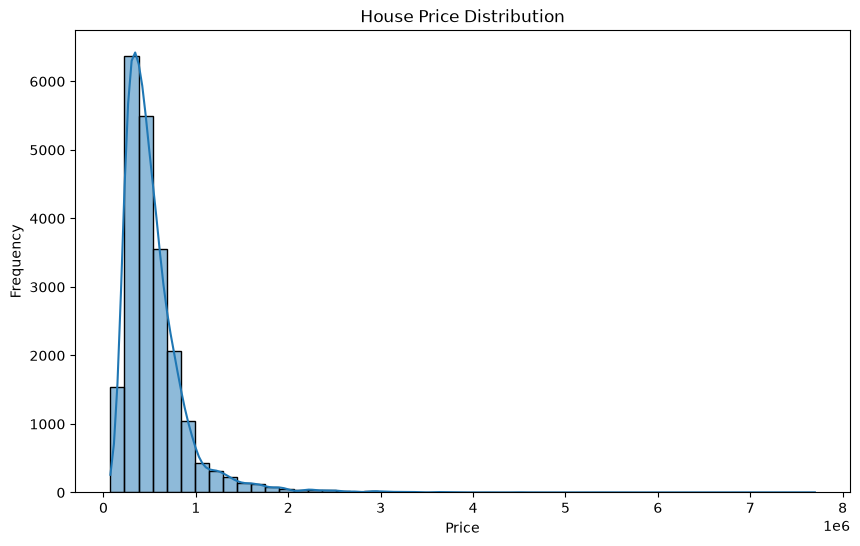

<Figure size 640x480 with 0 Axes>

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["price"],
    bins=50,
    kde=True
)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

plt.savefig(
    "../reports/images/house_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

In [16]:
df_ml

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,yr_built,lat,long,price
0,3,1.00,1180,5650,1.0,3,7,1955,47.5112,-122.257,221900.0
1,3,2.25,2570,7242,2.0,3,7,1951,47.7210,-122.319,538000.0
2,2,1.00,770,10000,1.0,3,6,1933,47.7379,-122.233,180000.0
3,4,3.00,1960,5000,1.0,5,7,1965,47.5208,-122.393,604000.0
4,3,2.00,1680,8080,1.0,3,8,1987,47.6168,-122.045,510000.0
...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,3,8,2009,47.6993,-122.346,360000.0
21609,4,2.50,2310,5813,2.0,3,8,2014,47.5107,-122.362,400000.0
21610,2,0.75,1020,1350,2.0,3,7,2009,47.5944,-122.299,402101.0
21611,3,2.50,1600,2388,2.0,3,8,2004,47.5345,-122.069,400000.0


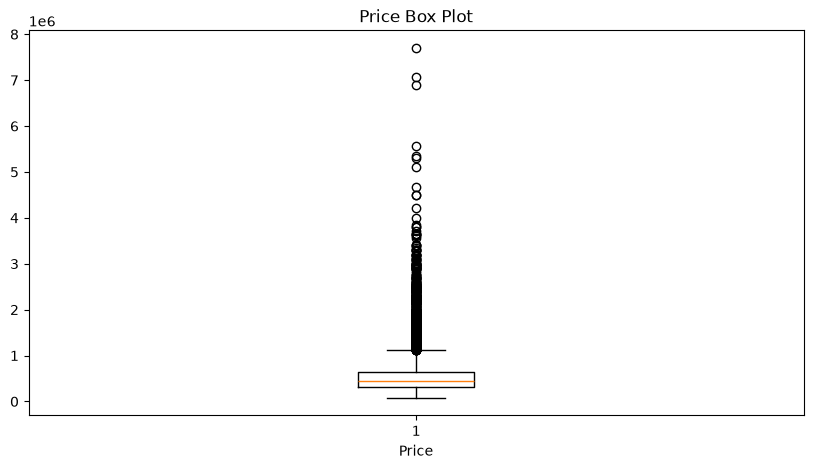

<Figure size 640x480 with 0 Axes>

In [23]:
plt.figure(figsize=(10, 5))
plt.boxplot(
    df_ml["price"],
)
plt.title("Price Box Plot")
plt.xlabel("Price")

plt.show()

plt.savefig(
    "../reports/images/house_price_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

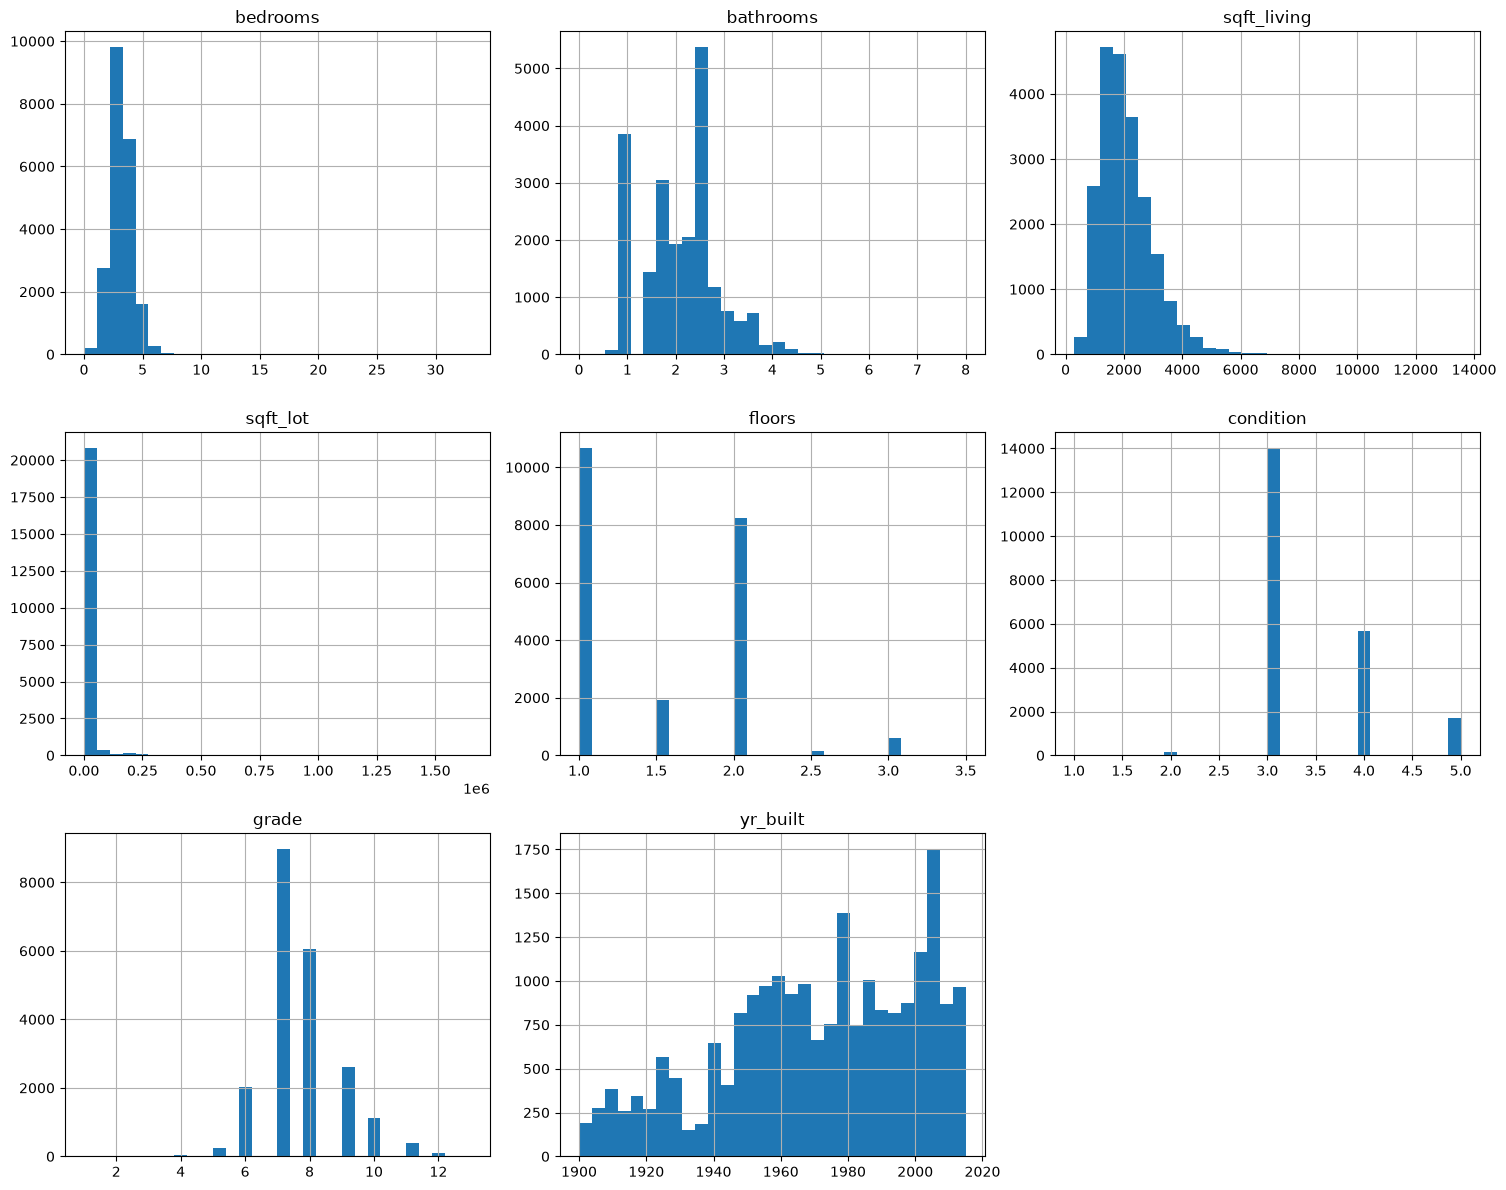

<Figure size 640x480 with 0 Axes>

In [29]:
numeric_features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "condition",
    "grade",
    "yr_built"
]

df_ml[numeric_features].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

plt.savefig(
    "../reports/images/numeric_features_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

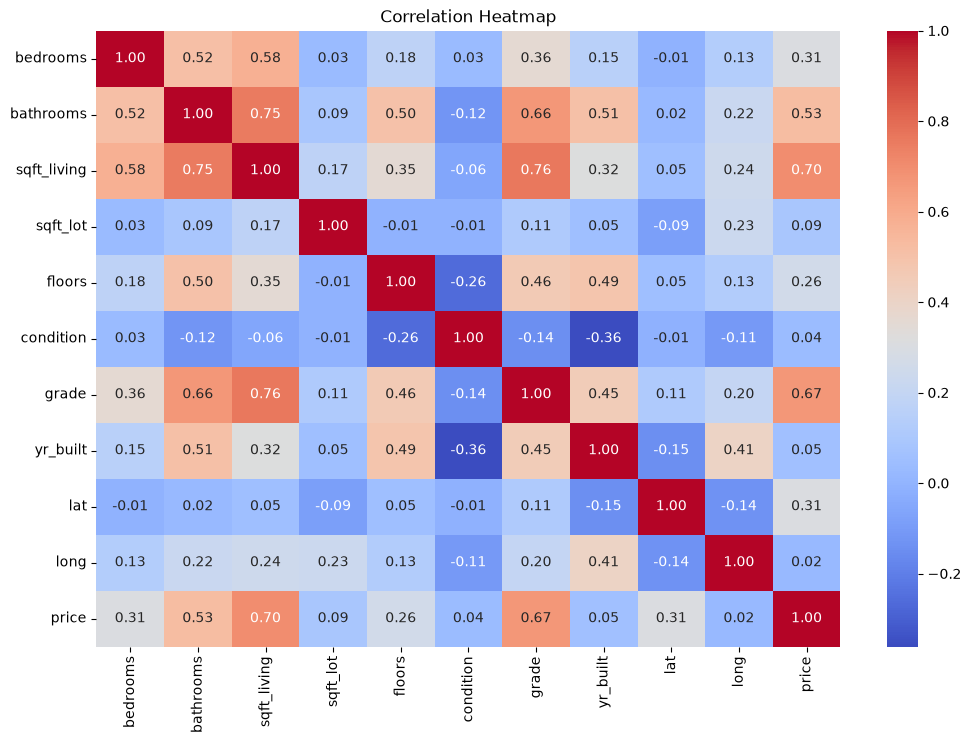

In [30]:
plt.figure(figsize=(12, 8))

correlation = df_ml.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

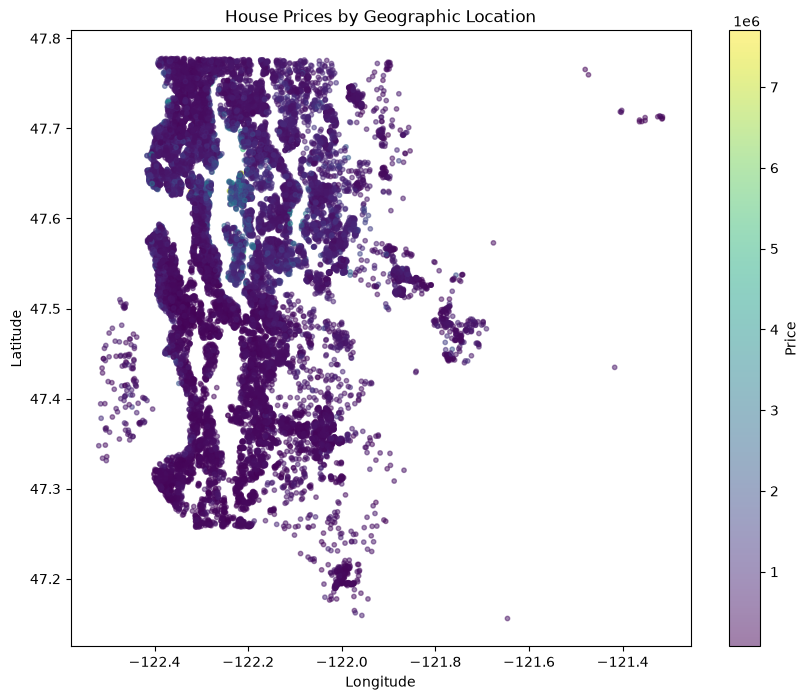

<Figure size 640x480 with 0 Axes>

In [31]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df_ml["long"],
    df_ml["lat"],
    c=df_ml["price"],
    alpha=0.5,
    s=10
)

plt.colorbar(scatter, label="Price")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("House Prices by Geographic Location")

plt.show()

plt.savefig(
    "../reports/images/house_prices_geolocation.png",
    dpi=300,
    bbox_inches="tight"
)